In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# SAM 3 Agent

This notebook shows an example of how an MLLM can use SAM 3 as a tool, i.e., "SAM 3 Agent", to segment more complex text queries such as "the leftmost child wearing blue vest".

## Env Setup

First install `sam3` in your environment using the [installation instructions](https://github.com/facebookresearch/sam3?tab=readme-ov-file#installation) in the repository.

In [12]:
import torch
# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook. If your card doesn't support it, try float16 instead
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# inference mode for the whole notebook. Disable if you need gradients
torch.inference_mode().__enter__()

In [13]:
import os

SAM3_ROOT = os.path.dirname(os.getcwd())
os.chdir(SAM3_ROOT)

# setup GPU to use -  A single GPU is good with the purpose of this demo
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
_ = os.system("nvidia-smi")

Wed Mar  4 18:46:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A800 80GB PCIe          On  |   00000000:D5:00.0 Off |                  Off |
| N/A   39C    P0             65W /  300W |   77055MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Build SAM3 Model

In [14]:
import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

sam3_root = os.path.dirname(sam3.__file__)
# bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
# model = build_sam3_image_model(bpe_path=bpe_path)
bpe_path = "/root/autodl-tmp/repos/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
#model = build_sam3_image_model(bpe_path=bpe_path)
#改为使用本地模型
ckpt_path = "/root/autodl-tmp/models/sam3_base/sam3.pt"  # 本地权重
model = build_sam3_image_model(
    bpe_path=bpe_path,
    checkpoint_path=ckpt_path,
    load_from_HF=False,   # 如果你的版本支持这个参数
    device="cuda",        # 可选
    eval_mode=True        # 可选
)
processor = Sam3Processor(model, confidence_threshold=0.5)

## LLM Setup

Config which MLLM to use, it can either be a model served by vLLM that you launch from your own machine or a model is served via external API. If you want to using a vLLM model, we also provided insturctions below.

In [15]:
LLM_CONFIGS = {
    # vLLM-served models
    "qwen3_vl_8b_thinking": {
        "provider": "vllm",
        "model": "Qwen/Qwen3-VL-8B-Thinking",
    },
    # models served via external APIs
    # add your own
}

model = "qwen3_vl_8b_thinking"
LLM_API_KEY = "DUMMY_API_KEY"

llm_config = LLM_CONFIGS[model]
llm_config["api_key"] = LLM_API_KEY
llm_config["name"] = model

# setup API endpoint
if llm_config["provider"] == "vllm":
    LLM_SERVER_URL = "http://0.0.0.0:8001/v1"  # replace this with your vLLM server address as needed
else:
    LLM_SERVER_URL = llm_config["base_url"]

### Setup vLLM server 
This step is only required if you are using a model served by vLLM, skip this step if you are calling LLM using an API like Gemini and GPT.

* Install vLLM (in a separate conda env from SAM 3 to avoid dependency conflicts).
  ```bash
    conda create -n vllm python=3.12
    pip install vllm --extra-index-url https://download.pytorch.org/whl/cu128
  ```
* Start vLLM server on the same machine of this notebook
  ```bash
    # qwen 3 VL 8B thinking
    vllm serve Qwen/Qwen3-VL-8B-Thinking --tensor-parallel-size 1 --allowed-local-media-path / --enforce-eager --port 8001
  ```

## Run SAM3 Agent Inference

In [17]:
from functools import partial
from IPython.display import display, Image
from sam3.agent.client_llm import send_generate_request as send_generate_request_orig
from sam3.agent.client_sam3 import call_sam_service as call_sam_service_orig
from sam3.agent.inference import run_single_image_inference

/root/autodl-tmp/repos/sam3/sam3/agent/agent_core.py:205: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (


------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: the leftmost child wearing blue vest
> Image path: /root/autodl-tmp/repos/sam3/assets/images/test_image.jpg



------------------------------ Round 1------------------------------



image_path /root/autodl-tmp/repos/sam3/assets/images/test_image.jpg
🔍 Calling model Qwen/Qwen3-VL-8B-Thinking...

>>> MLLM Response [start]
State that there is only one image in the message history (the raw input image). Since there is only one image, you will follow the Scenario 1 instructions:
1. Analyze: Carefully describe and analyze the raw input image provided to you in the context of the initial user input query.
The image shows a group of children on a basketball court. There are seven children visible, some wearing blue vests and others wearing red vests. The children are positioned across the court, with some running and some standing still. The court is marked with a green line, and ther

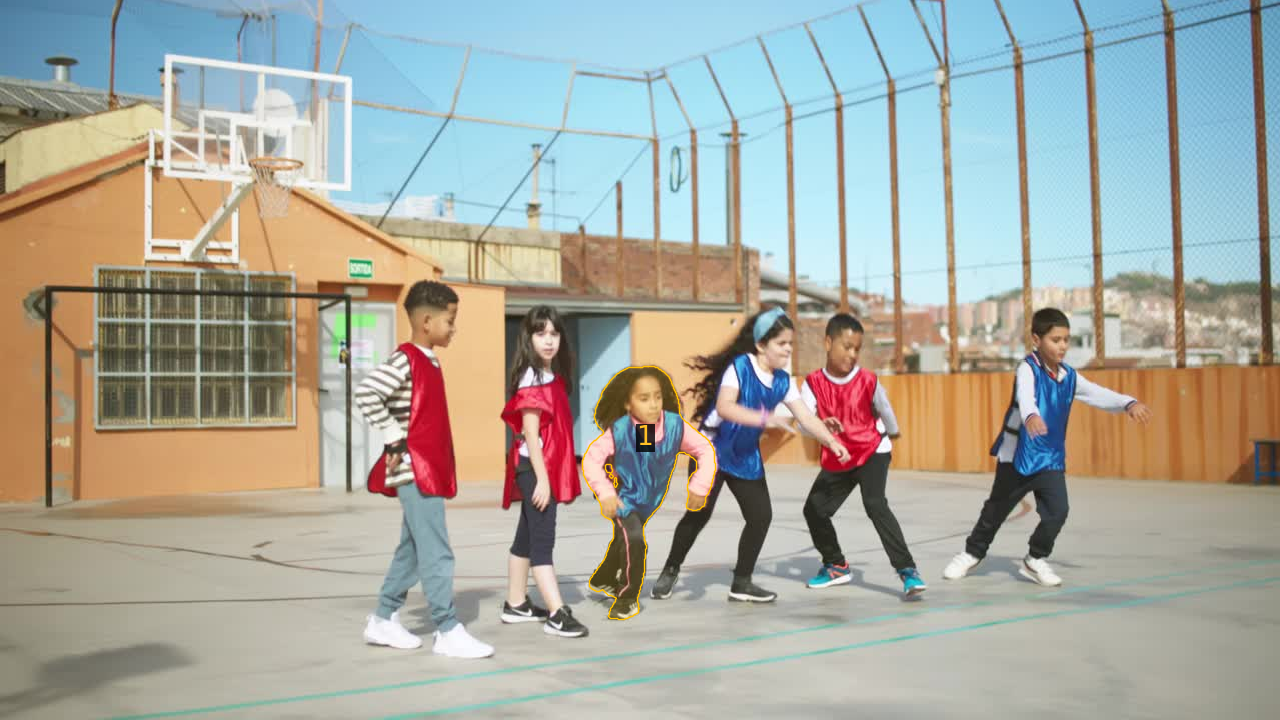

In [22]:
# prepare input args and run single image inference
image = "sam3/assets/images/test_image.jpg"
prompt = "the leftmost child wearing blue vest"
image = os.path.abspath(image)
send_generate_request = partial(send_generate_request_orig, server_url=LLM_SERVER_URL, model=llm_config["model"], api_key=llm_config["api_key"])
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)
output_image_path = run_single_image_inference(
    image, prompt, llm_config, send_generate_request, call_sam_service,
    debug=True, output_dir="agent_output"
)

# display output
if output_image_path is not None:
    display(Image(filename=output_image_path))